In [2]:
# -------------------------------
# Basic libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Preprocessing
# -------------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# -------------------------------
# Deep Learning (LSTM)
# -------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
file_path = r"C:\Users\kanis\OneDrive\Desktop\AircraftProject\outputs\LSTM_testing.csv"

df = pd.read_csv(file_path)

In [4]:
print(df.head())
print(df.shape)
print(df.columns)

   unit_number  time_in_cycles  sensor_measurement_2  sensor_measurement_3  \
0          0.0        0.000000              0.596215              0.421968   
1          0.0        0.003311              0.182965              0.504025   
2          0.0        0.006623              0.419558              0.464814   
3          0.0        0.009934              0.413249              0.391587   
4          0.0        0.013245              0.435331              0.471306   

   sensor_measurement_4  sensor_measurement_7  sensor_measurement_9  \
0              0.282214              0.608871              0.196475   
1              0.225240              0.800403              0.229042   
2              0.346130              0.651210              0.248506   
3              0.449867              0.643145              0.159080   
4              0.357974              0.661290              0.153410   

   sensor_measurement_11  sensor_measurement_12  sensor_measurement_17  \
0               0.273973      

In [5]:
df = df.drop(columns=['max_cycle'])

In [6]:
df['anomaly'] = df['anomaly'].map({-1: 1, 1: 0})

In [7]:
feature_cols = [
    col for col in df.columns
    if col not in ['unit_number', 'time_in_cycles', 'RUL']
]

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [9]:
df.to_csv("test_FD001_after_anomaly_scaled.csv", index=False) # for LSTM testing

In [10]:
WINDOW_SIZE = 30

In [11]:
def create_test_sequences(df, window_size, feature_cols):

    X_test = []
    seq_per_engine = []

    for engine_id in df['unit_number'].unique():

        engine_data = df[df['unit_number'] == engine_id]

        data_matrix = engine_data[feature_cols].values

        seq_count = 0

        for i in range(len(data_matrix) - window_size):
            X_test.append(data_matrix[i:i+window_size])
            seq_count += 1

        seq_per_engine.append(seq_count)

    X_test = np.array(X_test)

    return X_test, seq_per_engine

In [12]:
X_test, seq_per_engine = create_test_sequences(df, WINDOW_SIZE, feature_cols)

print("X_test shape:", X_test.shape)
print("Sequences per engine:", seq_per_engine[:10])

X_test shape: (10096, 30, 11)
Sequences per engine: [1, 19, 96, 76, 68, 75, 130, 136, 25, 162]


In [13]:
from tensorflow.keras.models import load_model

model = load_model("LSTM_RUL_FD001_model.keras")

In [14]:
WINDOW_SIZE = 30

def create_test_sequences(df, feature_cols, window_size):

    X_test = []
    seq_per_engine = []

    for uid in df['unit_number'].unique():

        engine_data = df[df['unit_number'] == uid]

        data = engine_data[feature_cols].values

        seq_count = 0

        for i in range(len(data) - window_size):
            X_test.append(data[i:i+window_size])
            seq_count += 1

        seq_per_engine.append(seq_count)

    return np.array(X_test), seq_per_engine

In [15]:
X_test, seq_per_engine = create_test_sequences(
    df,
    feature_cols,
    WINDOW_SIZE
)

print("X_test shape:", X_test.shape)

X_test shape: (10096, 30, 11)


In [16]:
df_test = df

In [17]:
y_pred_seq = model.predict(X_test)

print("Prediction shape:", y_pred_seq.shape)

316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Prediction shape: (10096, 1)


In [18]:
final_predictions = []

start = 0

for seq_count in seq_per_engine:

    last_index = start + seq_count - 1
    final_predictions.append(y_pred_seq[last_index][0])

    start += seq_count

print("Total engines:", len(final_predictions))

Total engines: 100


In [19]:
rul_file = r"C:\Users\kanis\OneDrive\Desktop\AircraftProject\data\RUL_FD001.txt"

true_rul = pd.read_csv(rul_file, header=None)
true_rul = true_rul[0].values

print("True RUL shape:", true_rul.shape)

True RUL shape: (100,)


In [20]:
rmse = np.sqrt(mean_squared_error(true_rul, final_predictions))

print("RMSE:", rmse)

RMSE: 30.773038880633568


In [21]:
results_df = pd.DataFrame({
    "unit_number": df_test['unit_number'].unique(),
    "True_RUL": true_rul,
    "Predicted_RUL": final_predictions
})

print(results_df.head())

   unit_number  True_RUL  Predicted_RUL
0     0.000000       112     173.227081
1     0.010101        98     112.953003
2     0.020202        69      30.129951
3     0.030303        82      52.179565
4     0.040404        91      61.894928


In [22]:
results_df.to_csv("LSTM_RUL_predictions_FD001.csv", index=False)

print("Prediction file saved")

Prediction file saved


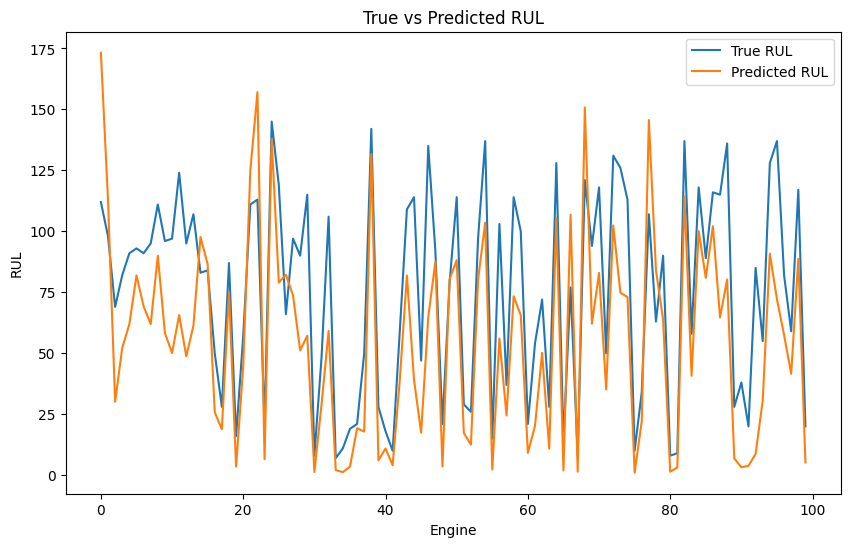

In [23]:
plt.figure(figsize=(10,6))

plt.plot(true_rul, label="True RUL")
plt.plot(final_predictions, label="Predicted RUL")

plt.xlabel("Engine")
plt.ylabel("RUL")

plt.title("True vs Predicted RUL")
plt.legend()

plt.show()

In [24]:

#-------------------------CLUSTERING---------------------#

In [25]:
print(results_df.head())

   unit_number  True_RUL  Predicted_RUL
0     0.000000       112     173.227081
1     0.010101        98     112.953003
2     0.020202        69      30.129951
3     0.030303        82      52.179565
4     0.040404        91      61.894928


In [26]:
from sklearn.cluster import KMeans

In [27]:
X_cluster = results_df[['Predicted_RUL']]

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42)

results_df['cluster'] = kmeans.fit_predict(X_cluster)

In [29]:
import numpy as np

centers = kmeans.cluster_centers_.flatten()

cluster_order = np.argsort(centers)

health_map = {
    cluster_order[0]: "Critical",
    cluster_order[1]: "Warning",
    cluster_order[2]: "Safe"
}

results_df['Health_Status'] = results_df['cluster'].map(health_map)

In [30]:
print(results_df.head())

   unit_number  True_RUL  Predicted_RUL  cluster Health_Status
0     0.000000       112     173.227081        1          Safe
1     0.010101        98     112.953003        1          Safe
2     0.020202        69      30.129951        0      Critical
3     0.030303        82      52.179565        2       Warning
4     0.040404        91      61.894928        2       Warning


In [ ]:
results_df.to_csv("Final_RUL_with_health_status.csv", index=False)

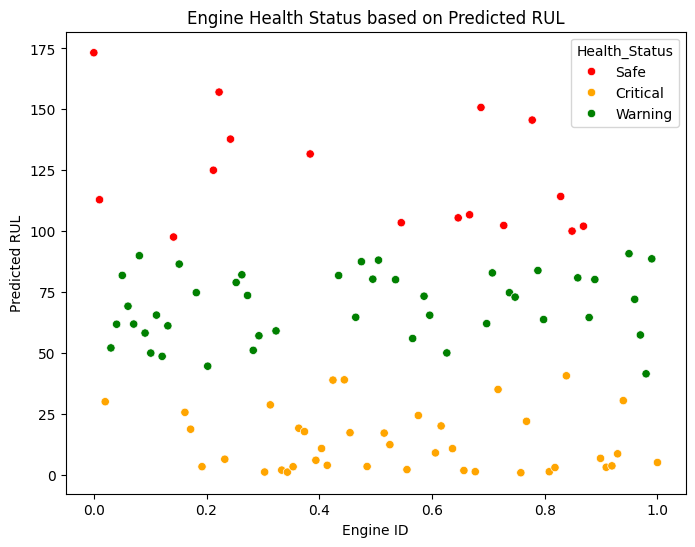

In [34]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=results_df['unit_number'],
    y=results_df['Predicted_RUL'],
    hue=results_df['Health_Status'],
    palette=['red','orange','green']
)

plt.title("Engine Health Status based on Predicted RUL")
plt.xlabel("Engine ID")
plt.ylabel("Predicted RUL")

plt.show()